# EDA — Distribusi Transaksi Harian & Mingguan per Kategori per User

Analisis distribusi:
1. **Nominal transaksi harian** per kategori (aggregat seluruh user)
2. **Jumlah transaksi per minggu** per kategori per user

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10

DATA_DIR = '../../../data/new'

df_trx = pd.read_csv(f'{DATA_DIR}/df_transaksi.csv', parse_dates=['timestamp'])
df_nas = pd.read_csv(f'{DATA_DIR}/df_nasabah.csv')

print(f'Transaksi : {df_trx.shape}')
print(f'Nasabah   : {df_nas.shape}')
df_trx.head(3)

Transaksi : (123525, 14)
Nasabah   : (500, 11)


,id_transaksi,id_user,timestamp,tipe_mutasi,deskripsi_mutasi,catatan_mutasi,mcc,nominal,sisa_saldo,kategori_besar,kategori_detail,label_anomali,gt_kategori_besar,gt_kategori_detail
0,TRX-13508,USR-290,2026-01-01 00:25:00,Debit,JANJI JIWA,-,5814,"27,496.5","5,769,272.2",Wants,F&B dan Nongkrong,0,Needs,F&B dan Nongkrong
1,TRX-13053,USR-287,2026-01-01 00:27:00,Debit,MIXUE INDONESIA,-,5814,"20,191.0","7,262,132.7",Wants,F&B dan Nongkrong,0,Wants,F&B dan Nongkrong
2,TRX-11943,USR-239,2026-01-01 00:54:00,Debit,SOLARIA,-,5812,"63,824.4","6,781,691.4",Wants,F&B dan Nongkrong,0,Needs,F&B dan Nongkrong


In [87]:

df = df_trx.copy()

df['tanggal']    = df['timestamp'].dt.date
df['minggu_num'] = df['timestamp'].dt.isocalendar().week.astype(int)
df['hari_nama']  = df['timestamp'].dt.day_name()


df = df.dropna(subset=['kategori_detail', 'kategori_besar'])
df_debit = df[df['tipe_mutasi'] == 'Debit'].copy()

KATEGORI_ORDER = sorted(df['kategori_detail'].unique())
print('Kategori Detail:', KATEGORI_ORDER)
print('Rentang tanggal:', df['tanggal'].min(), '-', df['tanggal'].max())

Kategori Detail: ['Belanja Online & Fashion', 'F&B Murah', 'F&B dan Nongkrong', 'Groceries & Kebutuhan Pokok', 'Hiburan & Langganan', 'Investasi & Finansial', 'Kesehatan & Perawatan Diri', 'Pemasukan Tambahan', 'Pendapatan Bulanan', 'Produktivitas & Digital', 'Tagihan & Utilitas', 'Transfer P2P', 'Transportasi']
Rentang tanggal: 2026-01-01 - 2026-03-31


---
## 1. Distribusi Nominal Harian per Kategori (seluruh user)

Setiap titik = total nominal transaksi satu user dalam satu hari untuk satu kategori (Debit).

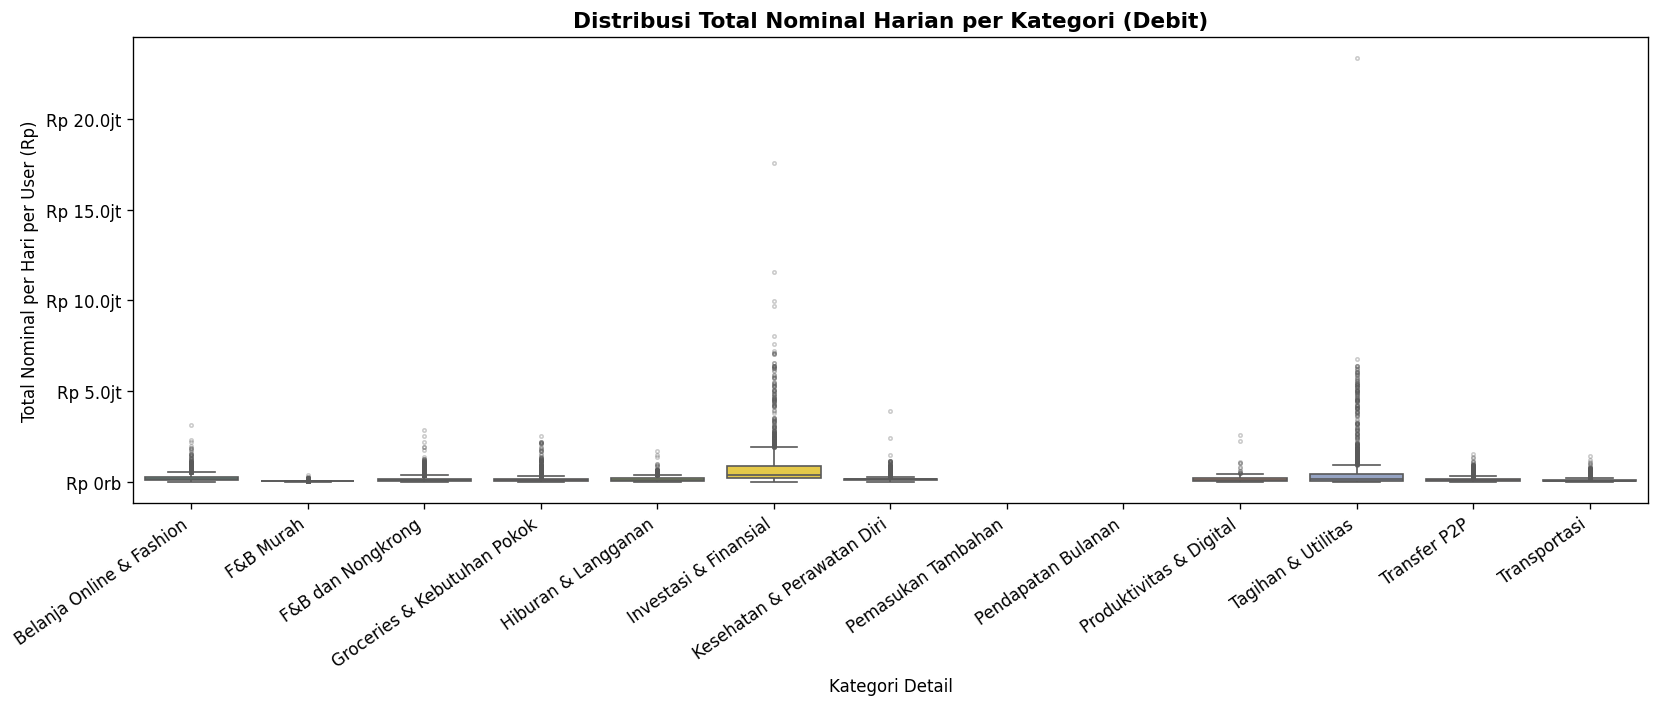


Statistik Nominal Harian per Kategori (Debit):


,count,mean,std,min,25%,50%,75%,95%,max
kategori_detail,,,,,,,,,
Belanja Online & Fashion,"3,323.0","199,540.0","213,875.0","2,000.0","71,513.0","144,178.0","248,986.0","572,860.0","3,116,398.0"
F&B Murah,"10,990.0","21,930.0","18,264.0","2,000.0","11,227.0","18,442.0","26,447.0","49,781.0","344,648.0"
F&B dan Nongkrong,"14,812.0","133,983.0","148,019.0","2,000.0","41,070.0","82,105.0","169,234.0","419,719.0","2,848,775.0"
Groceries & Kebutuhan Pokok,"10,648.0","119,559.0","152,681.0","2,000.0","37,578.0","65,843.0","148,435.0","384,637.0","2,543,731.0"
Hiburan & Langganan,"4,414.0","135,636.0","104,579.0","2,000.0","55,366.0","117,087.0","186,000.0","293,528.0","1,684,952.0"
Investasi & Finansial,"2,086.0","775,376.0","1,177,307.0","1,380.0","203,033.0","357,123.0","885,073.0","2,634,566.0","17,570,962.0"
Kesehatan & Perawatan Diri,"3,990.0","171,252.0","163,921.0","2,000.0","79,079.0","150,000.0","154,121.0","488,979.0","3,914,987.0"
Produktivitas & Digital,"1,324.0","119,578.0","146,534.0","2,000.0","36,600.0","70,000.0","202,447.0","350,000.0","2,562,250.0"
Tagihan & Utilitas,"2,013.0","542,986.0","1,173,262.0","2,000.0","44,254.0","125,964.0","402,973.0","2,674,185.0","23,354,284.0"


In [88]:
daily_user_kat = (
    df_debit
    .groupby(['id_user', 'tanggal', 'kategori_detail'])['nominal']
    .sum()
    .reset_index(name='total_nominal')
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=daily_user_kat,
    x='kategori_detail',
    y='total_nominal',
    order=KATEGORI_ORDER,
    palette='Set2',
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_title('Distribusi Total Nominal Harian per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Total Nominal per Hari per User (Rp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}rb'
))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('\nStatistik Nominal Harian per Kategori (Debit):')
daily_user_kat.groupby('kategori_detail')['total_nominal'].describe(
    percentiles=[.25, .5, .75, .95]
).round(0)

---
## 2. Rata-rata Nominal Harian per Kategori — per Hari dalam Seminggu

Heatmap pola pengeluaran berdasarkan hari (Senin–Minggu).

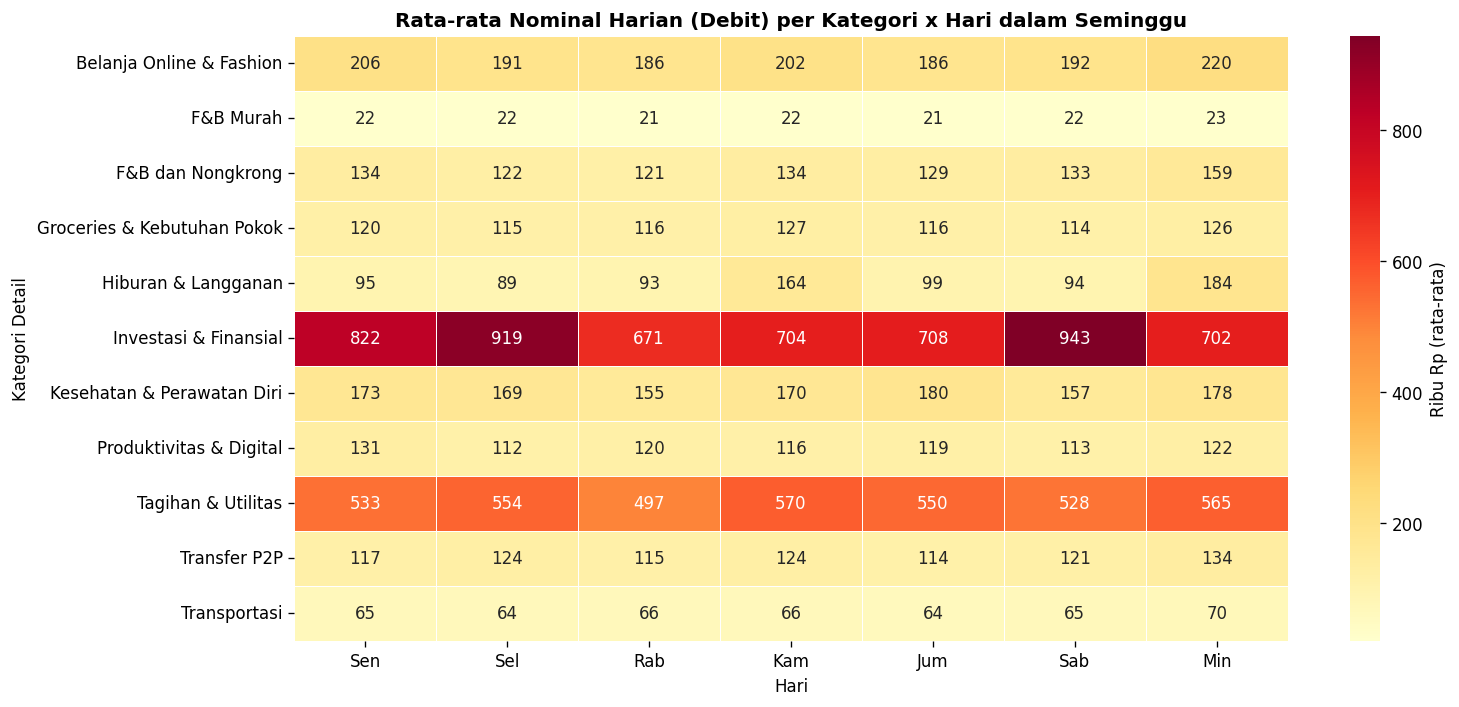

In [89]:
daily_user_kat['hari_nama'] = pd.to_datetime(daily_user_kat['tanggal']).dt.day_name()

DAY_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
DAY_LABEL = ['Sen', 'Sel', 'Rab', 'Kam', 'Jum', 'Sab', 'Min']

pivot_harian = (
    daily_user_kat
    .groupby(['kategori_detail', 'hari_nama'])['total_nominal']
    .mean()
    .unstack('hari_nama')
    .reindex(columns=DAY_ORDER)
)
pivot_harian.columns = DAY_LABEL

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(
    pivot_harian / 1e3,
    annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Ribu Rp (rata-rata)'},
    ax=ax
)
ax.set_title('Rata-rata Nominal Harian (Debit) per Kategori x Hari dalam Seminggu', fontsize=12, fontweight='bold')
ax.set_xlabel('Hari')
ax.set_ylabel('Kategori Detail')
plt.tight_layout()
plt.show()

---
## 3. Distribusi Jumlah Transaksi per Minggu per Kategori per User

Setiap titik = jumlah transaksi satu user dalam satu minggu untuk satu kategori.

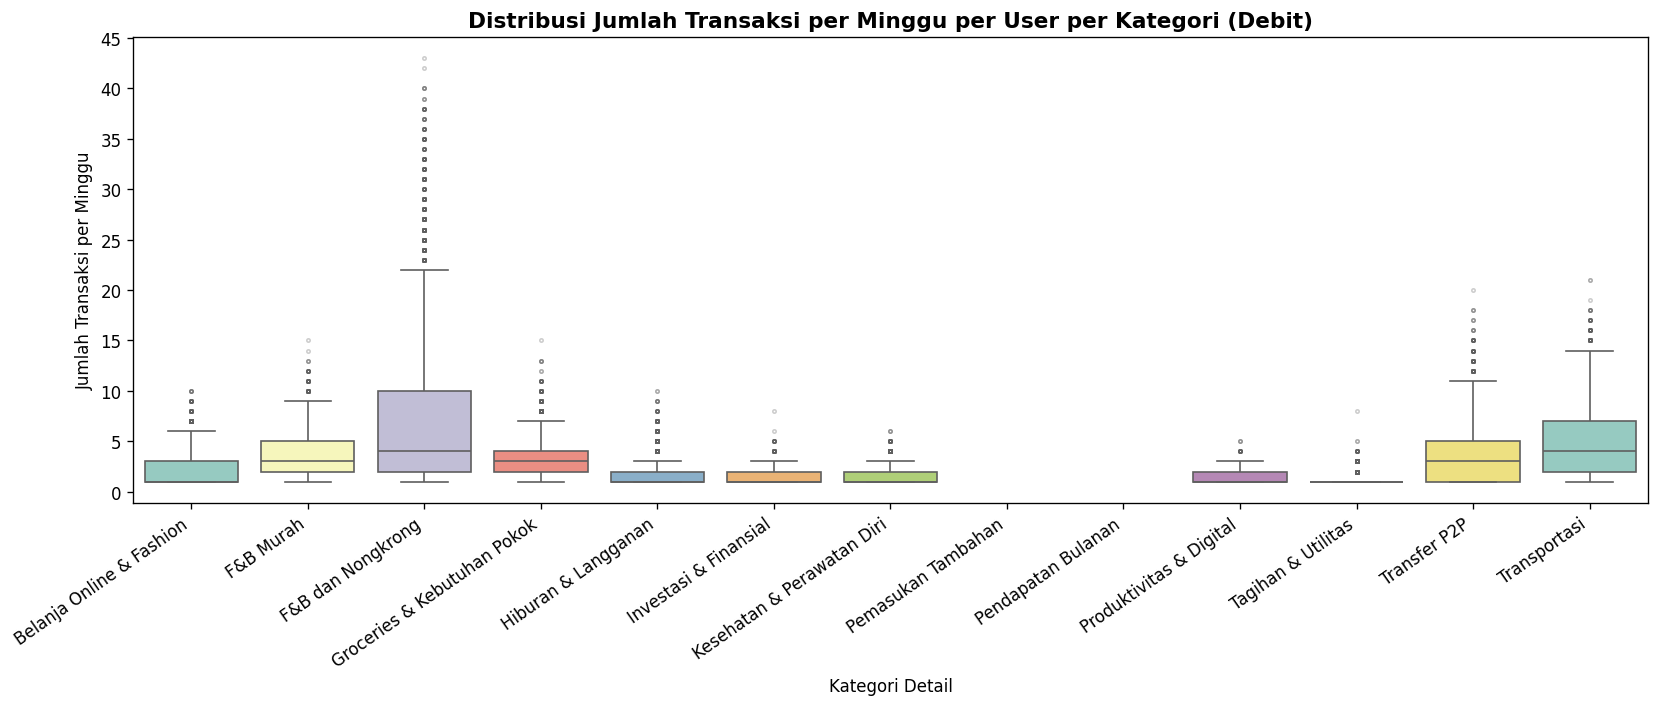


Statistik Jumlah Transaksi per Minggu per Kategori:


,count,mean,std,min,25%,50%,75%,95%,max
kategori_detail,,,,,,,,,
Belanja Online & Fashion,"1,806.0",2.4,2.0,1.0,1.0,1.0,3.0,7.0,10.0
F&B Murah,"4,328.0",3.4,2.2,1.0,2.0,3.0,5.0,8.0,15.0
F&B dan Nongkrong,"4,762.0",7.5,7.8,1.0,2.0,4.0,10.0,26.0,43.0
Groceries & Kebutuhan Pokok,"4,342.0",3.2,2.1,1.0,2.0,3.0,4.0,7.0,15.0
Hiburan & Langganan,"2,952.0",1.9,1.4,1.0,1.0,1.0,2.0,5.0,10.0
Investasi & Finansial,"1,622.0",1.4,0.8,1.0,1.0,1.0,2.0,3.0,8.0
Kesehatan & Perawatan Diri,"2,994.0",1.5,0.8,1.0,1.0,1.0,2.0,3.0,6.0
Produktivitas & Digital,"1,051.0",1.3,0.7,1.0,1.0,1.0,2.0,3.0,5.0
Tagihan & Utilitas,"1,604.0",1.3,0.6,1.0,1.0,1.0,1.0,3.0,8.0


In [90]:
# Aggregasi: hitung transaksi per user per minggu per kategori
weekly_user_kat = (
    df_debit
    .groupby(['id_user', 'minggu_num', 'kategori_detail'])['id_transaksi']
    .count()
    .reset_index(name='jumlah_trx')
)

fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=weekly_user_kat,
    x='kategori_detail',
    y='jumlah_trx',
    order=KATEGORI_ORDER,
    palette='Set3',
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_title('Distribusi Jumlah Transaksi per Minggu per User per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Jumlah Transaksi per Minggu')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

print('\nStatistik Jumlah Transaksi per Minggu per Kategori:')
weekly_user_kat.groupby('kategori_detail')['jumlah_trx'].describe(
    percentiles=[.25, .5, .75, .95]
).round(2)

---
## 4. Heatmap — Rata-rata Jumlah Transaksi per Minggu (Kategori x Minggu ke-N)

Tren mingguan masing-masing kategori sepanjang 3 bulan data.

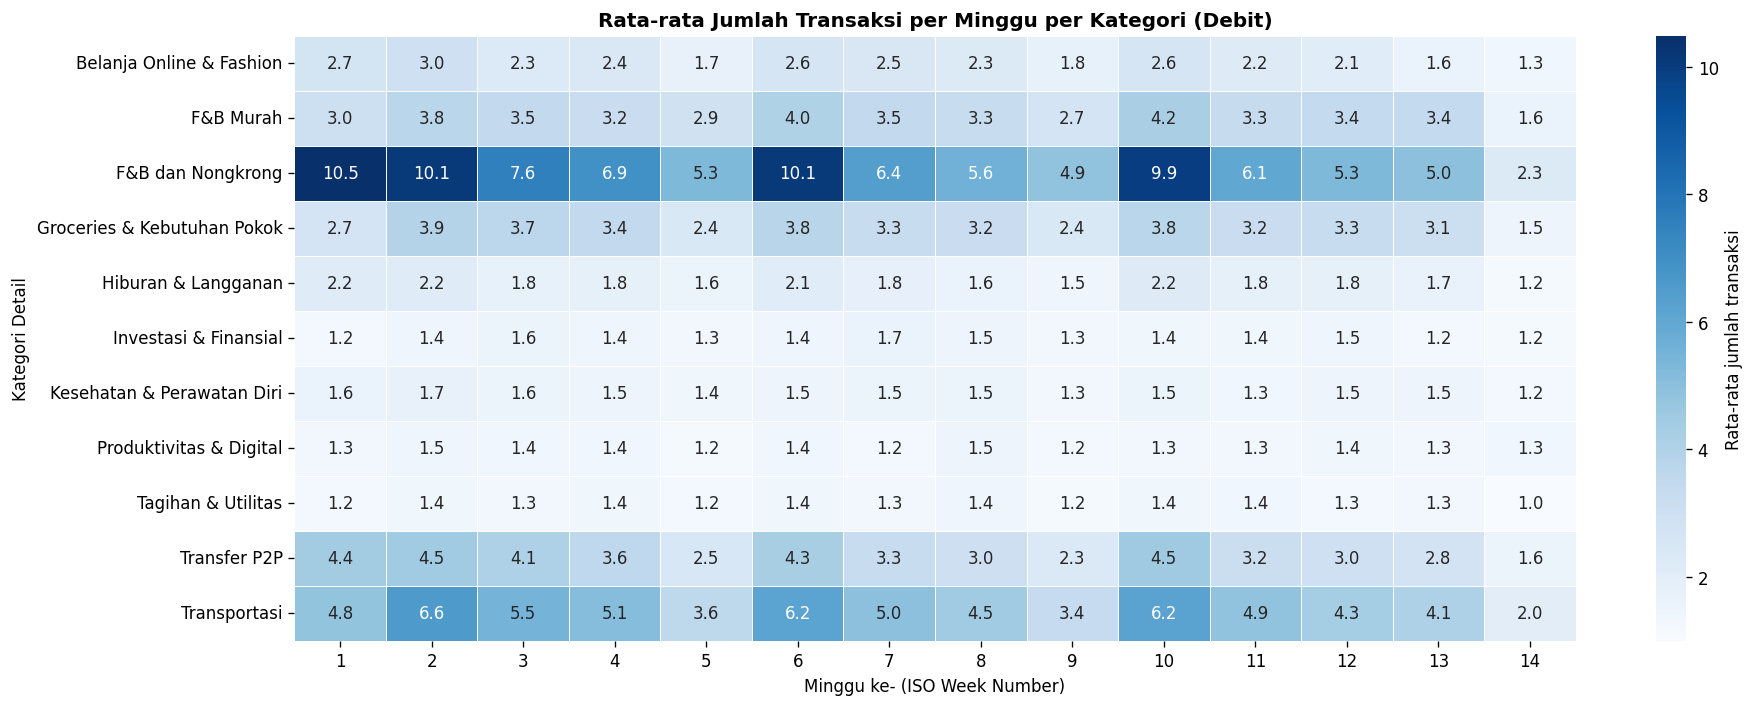

In [91]:
pivot_weekly = (
    weekly_user_kat
    .groupby(['kategori_detail', 'minggu_num'])['jumlah_trx']
    .mean()
    .unstack('minggu_num')
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    pivot_weekly,
    annot=True, fmt='.1f', cmap='Blues',
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Rata-rata jumlah transaksi'},
    ax=ax
)
ax.set_title('Rata-rata Jumlah Transaksi per Minggu per Kategori (Debit)', fontsize=12, fontweight='bold')
ax.set_xlabel('Minggu ke- (ISO Week Number)')
ax.set_ylabel('Kategori Detail')
plt.tight_layout()
plt.show()

---
## 5. Nominal Mingguan per Kategori — Tren & Distribusi Antar-User

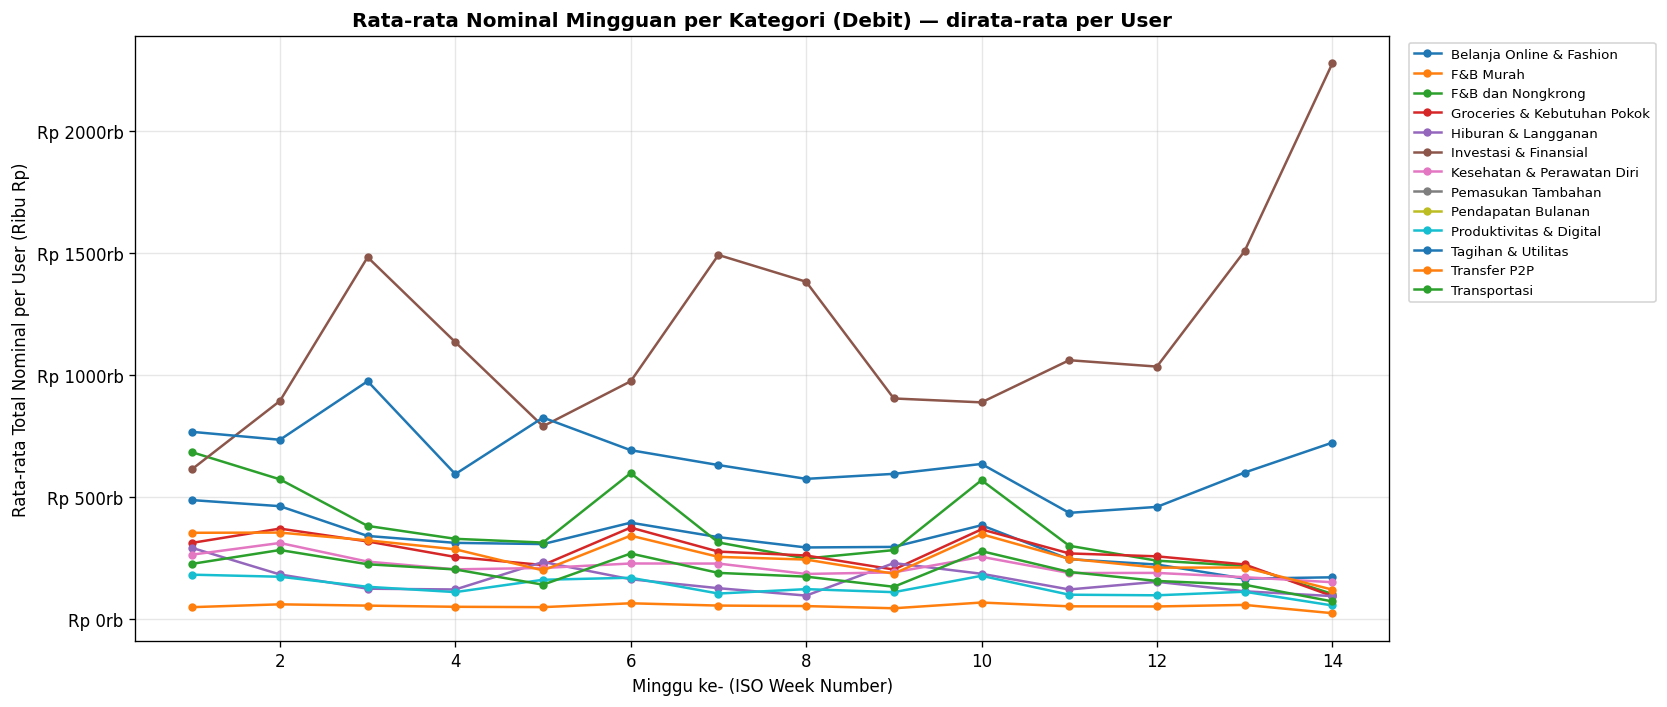

In [92]:
weekly_nominal = (
    df_debit
    .groupby(['id_user', 'minggu_num', 'kategori_detail'])['nominal']
    .sum()
    .reset_index(name='total_nominal')
)

agg_weekly = (
    weekly_nominal
    .groupby(['minggu_num', 'kategori_detail'])['total_nominal']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 6))

palette = sns.color_palette('tab10', n_colors=len(KATEGORI_ORDER))
for i, kat in enumerate(KATEGORI_ORDER):
    subset = agg_weekly[agg_weekly['kategori_detail'] == kat]
    ax.plot(subset['minggu_num'], subset['total_nominal'] / 1e3,
            marker='o', markersize=4, label=kat, color=palette[i])

ax.set_title('Rata-rata Nominal Mingguan per Kategori (Debit) — dirata-rata per User', fontsize=12, fontweight='bold')
ax.set_xlabel('Minggu ke- (ISO Week Number)')
ax.set_ylabel('Rata-rata Total Nominal per User (Ribu Rp)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'Rp {x:.0f}rb'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

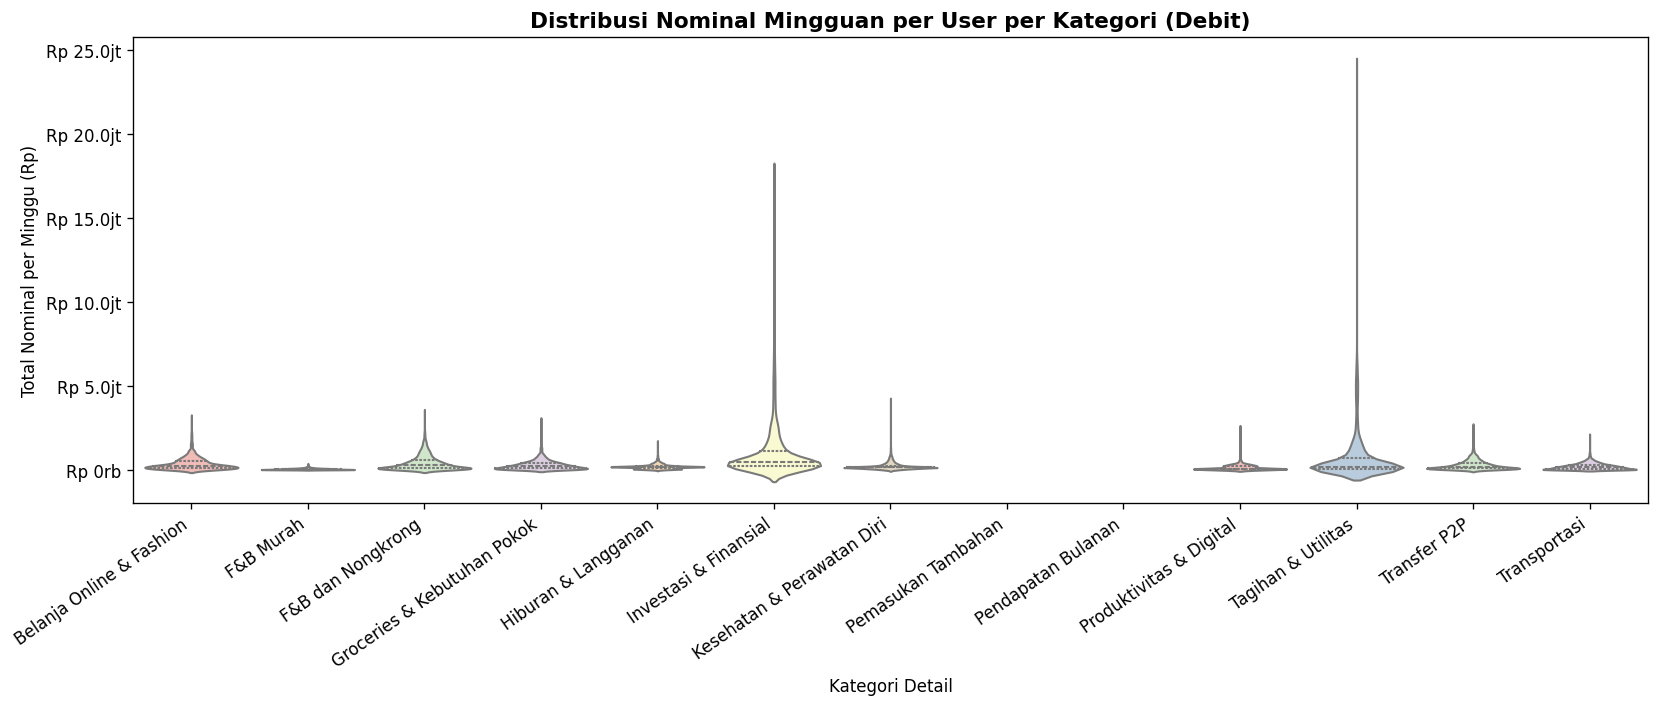

In [93]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(
    data=weekly_nominal,
    x='kategori_detail',
    y='total_nominal',
    order=KATEGORI_ORDER,
    palette='Pastel1',
    inner='quartile',
    ax=ax
)

ax.set_title('Distribusi Nominal Mingguan per User per Kategori (Debit)', fontsize=13, fontweight='bold')
ax.set_xlabel('Kategori Detail')
ax.set_ylabel('Total Nominal per Minggu (Rp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'Rp {x/1e6:.1f}jt' if x >= 1e6 else f'Rp {x/1e3:.0f}rb'
))
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout()
plt.show()

---
## 6. Rangkuman — Tabel Statistik Mingguan per Kategori

In [94]:
summary_nominal = weekly_nominal.groupby('kategori_detail')['total_nominal'].agg(
    median_nominal = 'median',
    mean_nominal   = 'mean',
    p75_nominal    = lambda x: x.quantile(0.75),
    p95_nominal    = lambda x: x.quantile(0.95),
)

summary_trx = weekly_user_kat.groupby('kategori_detail')['jumlah_trx'].agg(
    median_trx = 'median',
    mean_trx   = 'mean',
    p75_trx    = lambda x: x.quantile(0.75),
    p95_trx    = lambda x: x.quantile(0.95),
)

summary = summary_nominal.join(summary_trx).round(1)
summary.columns = [
    'Median Nominal/Minggu', 'Mean Nominal/Minggu', 'P75 Nominal', 'P95 Nominal',
    'Median Trx/Minggu', 'Mean Trx/Minggu', 'P75 Trx', 'P95 Trx'
]

pd.set_option('display.float_format', '{:,.1f}'.format)
summary

,Median Nominal/Minggu,Mean Nominal/Minggu,P75 Nominal,P95 Nominal,Median Trx/Minggu,Mean Trx/Minggu,P75 Trx,P95 Trx
kategori_detail,,,,,,,,
Belanja Online & Fashion,"245,840.0","367,149.0","519,185.5","1,059,196.8",1.0,2.4,3.0,7.0
F&B Murah,"45,042.6","55,686.5","78,330.7","138,230.2",3.0,3.4,5.0,8.0
F&B dan Nongkrong,"268,104.4","416,747.5","584,903.6","1,333,482.3",4.0,7.5,10.0,26.0
Groceries & Kebutuhan Pokok,"214,880.6","293,197.7","406,814.4","822,629.3",3.0,3.2,4.0,7.0
Hiburan & Langganan,"186,000.0","202,810.7","242,856.4","464,343.0",1.0,1.8,2.0,5.0
Investasi & Finansial,"454,048.0","997,185.5","1,101,972.2","4,104,544.3",1.0,1.4,2.0,3.0
Kesehatan & Perawatan Diri,"150,000.0","228,221.9","261,094.1","639,631.9",1.0,1.5,2.0,3.0
Produktivitas & Digital,"79,000.0","150,639.2","215,000.0","370,148.8",1.0,1.3,2.0,3.0
Tagihan & Utilitas,"187,138.0","681,441.0","692,853.3","3,773,514.3",1.0,1.3,1.0,3.0


---
## 7. Rincian per User — Nominal & Jumlah Transaksi per Kategori per Minggu

Tabel pivot per user: baris = kategori, kolom = minggu (sub-kolom: **Nominal** dan **Trx**).

In [95]:
def fmt_nominal(x):
    if pd.isna(x) or x == 0:
        return '-'
    elif x >= 1_000_000:
        return f'Rp {x/1_000_000:.2f}jt'
    return f'Rp {x/1_000:.0f}rb'


def fmt_trx(x):
    if pd.isna(x) or x == 0:
        return '-'
    return str(int(x))


def user_weekly_table(user_id, df_debit):
    df_u = df_debit[df_debit['id_user'] == user_id].copy()

    grp = df_u.groupby(['kategori_detail', 'minggu_num']).agg(
        nominal=('nominal', 'sum'),
        trx=('id_transaksi', 'count')
    ).reset_index()

    weeks = sorted(grp['minggu_num'].unique())

    piv_nominal = grp.pivot(index='kategori_detail', columns='minggu_num', values='nominal').fillna(0)
    piv_trx     = grp.pivot(index='kategori_detail', columns='minggu_num', values='trx').fillna(0)

    frames = []
    for w in weeks:
        col_label = f'Minggu {w}'
        frames.append(piv_nominal[w].rename((col_label, 'Nominal')))
        frames.append(piv_trx[w].rename((col_label, 'Trx')))

    result = pd.concat(frames, axis=1)
    result.columns = pd.MultiIndex.from_tuples(result.columns)
    result.index.name = 'Kategori'

    display_df = result.copy().astype(object)
    for w in weeks:
        col_label = f'Minggu {w}'
        display_df[(col_label, 'Nominal')] = result[(col_label, 'Nominal')].map(fmt_nominal)
        display_df[(col_label, 'Trx')]     = result[(col_label, 'Trx')].map(fmt_trx)

    return display_df


# Pilih 2 user sebagai contoh
SAMPLE_USERS = ['USR-001', 'USR-002']

for uid in SAMPLE_USERS:
    sep = '=' * 80
    print(f'\n{sep}')
    print(f'  USER: {uid}')
    print(sep)
    tbl = user_weekly_table(uid, df_debit)
    display(tbl)


  USER: USR-001


Minggu 1      Minggu 2     Minggu 3      \
                               Nominal Trx   Nominal Trx  Nominal Trx   
Kategori                                                                
Belanja Online & Fashion     Rp 1.40jt   5         -   -        -   -   
F&B Murah                            -   -    Rp 6rb   1        -   -   
F&B dan Nongkrong            Rp 1.80jt  22  Rp 232rb   8   Rp 3rb   1   
Groceries & Kebutuhan Pokok   Rp 826rb   3         -   -        -   -   
Hiburan & Langganan           Rp 641rb   3   Rp 53rb   1        -   -   
Investasi & Finansial         Rp 313rb   1         -   -        -   -   
Kesehatan & Perawatan Diri    Rp 211rb   2         -   -        -   -   
Produktivitas & Digital       Rp 350rb   1         -   -        -   -   
Transfer P2P                  Rp 627rb   4         -   -        -   -   
Transportasi                  Rp 336rb   3    Rp 3rb   1        -   -   

                             Minggu 4      Minggu 5      ... Minggu 10      \
                              Nominal Trx   Nominal Trx  ...   Nominal Trx   
Kategori                                                 ...                 
Belanja Online & Fashion            -   -         -   -  ...  Rp 234rb   1   
F&B Murah                           -   -         -   -  ...    Rp 9rb   2   
F&B dan Nongkrong            Rp 349rb   5   Rp 10rb   1  ...  Rp 989rb   2   
Groceries & Kebutuhan Pokok         -   -  Rp 583rb   1  ...  Rp 954rb   6   
Hiburan & Langganan           Rp 41rb   1  Rp 186rb   1  ...   Rp 28rb   1   
Investasi & Finansial               -   -         -   -  ...         -   -   
Kesehatan & Perawatan Diri          -   -  Rp 150rb   1  ...         -   -   
Produktivitas & Digital             -   -         -   -  ...         -   -   
Transfer P2P                        -   -  Rp 255rb   2  ...         -   -   
Transportasi                  Rp 81rb   5         -   -  ...  Rp 114rb   5   

                            Minggu 11     Minggu 12     Minggu 13      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion            -   -         -   -         -   -   
F&B Murah                     Rp 73rb   4   Rp 19rb   3   Rp 48rb   3   
F&B dan Nongkrong             Rp 86rb   1         -   -  Rp 130rb   2   
Groceries & Kebutuhan Pokok    Rp 4rb   1         -   -         -   -   
Hiburan & Langganan                 -   -         -   -  Rp 230rb   1   
Investasi & Finansial               -   -         -   -         -   -   
Kesehatan & Perawatan Diri          -   -         -   -         -   -   
Produktivitas & Digital             -   -         -   -         -   -   
Transfer P2P                        -   -         -   -         -   -   
Transportasi                 Rp 145rb   4   Rp 34rb   2  Rp 314rb   3   

                            Minggu 14      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B Murah                      Rp 7rb   1  
F&B dan Nongkrong                   -   -  
Groceries & Kebutuhan Pokok         -   -  
Hiburan & Langganan                 -   -  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Transfer P2P                        -   -  
Transportasi                        -   -  

[10 rows x 28 columns]


  USER: USR-002


Minggu 1     Minggu 2       Minggu 5      \
                              Nominal Trx  Nominal Trx    Nominal Trx   
Kategori                                                                
Belanja Online & Fashion     Rp 159rb   1        -   -    Rp 99rb   1   
F&B Murah                      Rp 6rb   1        -   -          -   -   
F&B dan Nongkrong            Rp 879rb   9        -   -  Rp 1.10jt  13   
Groceries & Kebutuhan Pokok  Rp 664rb   2        -   -   Rp 166rb   2   
Hiburan & Langganan          Rp 544rb   3        -   -   Rp 379rb   4   
Kesehatan & Perawatan Diri   Rp 461rb   2        -   -   Rp 150rb   1   
Produktivitas & Digital             -   -        -   -   Rp 206rb   1   
Transfer P2P                 Rp 108rb   2        -   -          -   -   
Transportasi                 Rp 303rb   4  Rp 12rb   1   Rp 342rb   6   

                             Minggu 6      Minggu 8      Minggu 9      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion            -   -   Rp 62rb   2         -   -   
F&B Murah                     Rp 14rb   2         -   -   Rp 19rb   1   
F&B dan Nongkrong            Rp 285rb   3  Rp 263rb   5  Rp 367rb   6   
Groceries & Kebutuhan Pokok    Rp 7rb   1         -   -   Rp 48rb   1   
Hiburan & Langganan                 -   -         -   -  Rp 551rb   3   
Kesehatan & Perawatan Diri          -   -         -   -  Rp 150rb   1   
Produktivitas & Digital             -   -         -   -         -   -   
Transfer P2P                        -   -   Rp 31rb   1  Rp 147rb   3   
Transportasi                   Rp 5rb   1   Rp 36rb   3   Rp 36rb   2   

                            Minggu 10      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion     Rp 391rb   3  
F&B Murah                     Rp 16rb   1  
F&B dan Nongkrong            Rp 193rb   4  
Groceries & Kebutuhan Pokok    Rp 5rb   1  
Hiburan & Langganan          Rp 251rb   2  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Transfer P2P                        -   -  
Transportasi                  Rp 36rb   2

---
## 8. Pola Transaksi per Persona & Segmen Pekerjaan

Menampilkan **1 user representatif per kombinasi** segmen demografi × persona dasar (3 × 3 = 9 user).

| Segmen | Keterangan |
|---|---|
| **Mahasiswa** | Pemasukan rendah (~1–3 jt) |
| **First Jobber** | Pemasukan menengah (~4–6 jt), baru kerja |
| **Profesional** | Pemasukan tinggi (~9–19 jt), mapan |

Persona: **Spendthrift** (boros) · **Unconflicted** (seimbang) · **Tightwad** (hemat)

In [96]:
SAMPLE_GRID = {
    ('Mahasiswa',    'Spendthrift'):  'USR-156',
    ('Mahasiswa',    'Unconflicted'): 'USR-074',
    ('Mahasiswa',    'Tightwad'):     'USR-105',
    ('First Jobber', 'Spendthrift'):  'USR-395',
    ('First Jobber', 'Unconflicted'): 'USR-362',
    ('First Jobber', 'Tightwad'):     'USR-375',
    ('Profesional',  'Spendthrift'):  'USR-409',
    ('Profesional',  'Unconflicted'): 'USR-451',
    ('Profesional',  'Tightwad'):     'USR-476',
}

nasabah_info = df_nas.set_index('id_user')[['segmen_demografi', 'persona_dasar', 'gaji_bulanan']].to_dict('index')

SEGMEN_ORDER = ['Mahasiswa', 'First Jobber', 'Profesional']
PERSONA_ORDER = ['Spendthrift', 'Unconflicted', 'Tightwad']

for segmen in SEGMEN_ORDER:
    block_sep = '\u2593' * 80
    print(f'\n{block_sep}')
    print(f'  SEGMEN: {segmen.upper()}')
    print(f'{block_sep}')

    for persona in PERSONA_ORDER:
        uid = SAMPLE_GRID[(segmen, persona)]
        info = nasabah_info.get(uid, {})
        gaji = info.get('gaji_bulanan', 0)
        gaji_fmt = f'Rp {gaji/1_000_000:.2f}jt' if gaji >= 1_000_000 else f'Rp {gaji/1_000:.0f}rb'

        sep = '-' * 80
        print(f'\n  {persona:<14}  |  {uid}  |  Gaji: {gaji_fmt}')
        print(sep)

        tbl = user_weekly_table(uid, df_debit)
        display(tbl)



▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
  SEGMEN: MAHASISWA
▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

  Spendthrift     |  USR-156  |  Gaji: Rp 2.97jt
--------------------------------------------------------------------------------


Minggu 1       Minggu 2     Minggu 3      \
                               Nominal Trx    Nominal Trx  Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion      Rp 615rb   3   Rp 616rb   3        -   -   
F&B Murah                      Rp 10rb   1          -   -        -   -   
F&B dan Nongkrong            Rp 1.56jt  23  Rp 1.39jt  11        -   -   
Groceries & Kebutuhan Pokok   Rp 180rb   2          -   -        -   -   
Hiburan & Langganan           Rp 262rb   2          -   -        -   -   
Investasi & Finansial         Rp 297rb   1          -   -        -   -   
Kesehatan & Perawatan Diri    Rp 150rb   1    Rp 68rb   1        -   -   
Transfer P2P                  Rp 659rb   8          -   -        -   -   
Transportasi                   Rp 31rb   3    Rp 83rb   3   Rp 6rb   1   

                             Minggu 4      Minggu 5      ... Minggu 8      \
                              Nominal Trx   Nominal Trx  ...  Nominal Trx   
Kategori                                                 ...                
Belanja Online & Fashion            -   -  Rp 251rb   1  ...        -   -   
F&B Murah                           -   -         -   -  ...   Rp 2rb   1   
F&B dan Nongkrong            Rp 685rb   6  Rp 645rb   5  ...        -   -   
Groceries & Kebutuhan Pokok         -   -         -   -  ...        -   -   
Hiburan & Langganan           Rp 33rb   1  Rp 580rb   3  ...        -   -   
Investasi & Finansial               -   -         -   -  ...        -   -   
Kesehatan & Perawatan Diri    Rp 82rb   1  Rp 150rb   1  ...        -   -   
Transfer P2P                        -   -   Rp 66rb   1  ...        -   -   
Transportasi                  Rp 16rb   1  Rp 239rb   5  ...        -   -   

                             Minggu 9     Minggu 10     Minggu 11      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion     Rp 551rb   2  Rp 187rb   1         -   -   
F&B Murah                     Rp 67rb   3         -   -         -   -   
F&B dan Nongkrong            Rp 162rb   5  Rp 384rb   5         -   -   
Groceries & Kebutuhan Pokok         -   -         -   -         -   -   
Hiburan & Langganan          Rp 256rb   3  Rp 185rb   3         -   -   
Investasi & Finansial               -   -  Rp 297rb   1         -   -   
Kesehatan & Perawatan Diri   Rp 150rb   1         -   -         -   -   
Transfer P2P                 Rp 392rb   6  Rp 229rb   3         -   -   
Transportasi                  Rp 23rb   2   Rp 83rb   4    Rp 3rb   1   

                            Minggu 13      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B Murah                           -   -  
F&B dan Nongkrong                   -   -  
Groceries & Kebutuhan Pokok         -   -  
Hiburan & Langganan                 -   -  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Transfer P2P                        -   -  
Transportasi                   Rp 3rb   1  

[9 rows x 22 columns]


  Unconflicted    |  USR-074  |  Gaji: Rp 3.21jt
--------------------------------------------------------------------------------


Minggu 1       Minggu 2      Minggu 3      \
                              Nominal Trx    Nominal Trx   Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion            -   -          -   -         -   -   
F&B Murah                     Rp 50rb   2    Rp 81rb   4   Rp 28rb   2   
F&B dan Nongkrong            Rp 483rb   8  Rp 1.02jt   9   Rp 57rb   2   
Groceries & Kebutuhan Pokok  Rp 644rb   3   Rp 325rb   2         -   -   
Hiburan & Langganan          Rp 322rb   2   Rp 127rb   1         -   -   
Investasi & Finansial        Rp 258rb   1    Rp 63rb   1         -   -   
Kesehatan & Perawatan Diri   Rp 150rb   1          -   -         -   -   
Produktivitas & Digital             -   -    Rp 29rb   1         -   -   
Tagihan & Utilitas                  -   -    Rp 46rb   1         -   -   
Transfer P2P                 Rp 184rb   2   Rp 613rb   8   Rp 56rb   1   
Transportasi                 Rp 484rb   6   Rp 637rb  11  Rp 277rb   3   

                             Minggu 5      Minggu 6      Minggu 7      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion            -   -  Rp 133rb   1         -   -   
F&B Murah                           -   -  Rp 104rb   6         -   -   
F&B dan Nongkrong             Rp 63rb   1  Rp 254rb   8  Rp 705rb   8   
Groceries & Kebutuhan Pokok         -   -  Rp 201rb   3  Rp 159rb   1   
Hiburan & Langganan          Rp 186rb   1  Rp 158rb   1         -   -   
Investasi & Finansial               -   -   Rp 52rb   1         -   -   
Kesehatan & Perawatan Diri   Rp 150rb   1   Rp 48rb   1         -   -   
Produktivitas & Digital             -   -   Rp 79rb   1         -   -   
Tagihan & Utilitas                  -   -         -   -         -   -   
Transfer P2P                        -   -  Rp 209rb   2  Rp 132rb   1   
Transportasi                        -   -  Rp 420rb   6  Rp 153rb   6   

                             Minggu 9     Minggu 10     Minggu 11      
                              Nominal Trx   Nominal Trx   Nominal Trx  
Kategori                                                               
Belanja Online & Fashion            -   -  Rp 455rb   1         -   -  
F&B Murah                           -   -   Rp 22rb   2         -   -  
F&B dan Nongkrong            Rp 452rb   4  Rp 575rb  10         -   -  
Groceries & Kebutuhan Pokok         -   -  Rp 473rb   7   Rp 31rb   1  
Hiburan & Langganan          Rp 186rb   1         -   -         -   -  
Investasi & Finansial               -   -         -   -         -   -  
Kesehatan & Perawatan Diri   Rp 349rb   3         -   -         -   -  
Produktivitas & Digital             -   -         -   -         -   -  
Tagihan & Utilitas                  -   -         -   -         -   -  
Transfer P2P                  Rp 50rb   1  Rp 142rb   2   Rp 39rb   1  
Transportasi                 Rp 105rb   2  Rp 305rb   7   Rp 28rb   1


  Tightwad        |  USR-105  |  Gaji: Rp 1.60jt
--------------------------------------------------------------------------------


...

Minggu 1       Minggu 2       Minggu 3      \
                              Nominal Trx    Nominal Trx    Nominal Trx   
Kategori                                                                  
Belanja Online & Fashion      Rp 43rb   1   Rp 920rb   7   Rp 461rb   6   
F&B Murah                     Rp 33rb   1    Rp 21rb   1          -   -   
F&B dan Nongkrong            Rp 929rb  20  Rp 1.38jt  36   Rp 926rb  28   
Groceries & Kebutuhan Pokok   Rp 87rb   2   Rp 433rb   7   Rp 182rb   3   
Hiburan & Langganan          Rp 388rb   5   Rp 270rb   5    Rp 62rb   2   
Investasi & Finansial        Rp 389rb   1  Rp 2.75jt   2  Rp 1.09jt   4   
Kesehatan & Perawatan Diri   Rp 622rb   3   Rp 113rb   1    Rp 98rb   1   
Produktivitas & Digital             -   -   Rp 237rb   3          -   -   
Tagihan & Utilitas                  -   -          -   -          -   -   
Transfer P2P                 Rp 148rb   3   Rp 482rb   7   Rp 435rb   6   
Transportasi                 Rp 156rb   8   Rp 310rb   9   Rp 879rb  10   

                              Minggu 4       Minggu 5      ...  Minggu 10      \
                               Nominal Trx    Nominal Trx  ...    Nominal Trx   
Kategori                                                   ...                  
Belanja Online & Fashion     Rp 2.03jt   6   Rp 315rb   4  ...   Rp 923rb   8   
F&B Murah                      Rp 39rb   3    Rp 54rb   3  ...    Rp 18rb   2   
F&B dan Nongkrong             Rp 901rb  26   Rp 788rb  22  ...  Rp 1.34jt  36   
Groceries & Kebutuhan Pokok   Rp 318rb   6   Rp 218rb   5  ...   Rp 301rb   5   
Hiburan & Langganan           Rp 106rb   2   Rp 846rb   8  ...   Rp 110rb   2   
Investasi & Finansial         Rp 966rb   2  Rp 1.55jt   1  ...          -   -   
Kesehatan & Perawatan Diri    Rp 300rb   3   Rp 180rb   2  ...          -   -   
Produktivitas & Digital       Rp 104rb   2    Rp 50rb   1  ...          -   -   
Tagihan & Utilitas            Rp 311rb   1    Rp 59rb   1  ...          -   -   
Transfer P2P                  Rp 775rb  10  Rp 1.77jt  10  ...  Rp 1.17jt  12   
Transportasi                  Rp 208rb   5   Rp 499rb  12  ...   Rp 521rb  10   

                             Minggu 11      Minggu 12      Minggu 13      \
                               Nominal Trx    Nominal Trx    Nominal Trx   
Kategori                                                                   
Belanja Online & Fashion      Rp 452rb   3  Rp 1.34jt  10   Rp 500rb   4   
F&B Murah                      Rp 15rb   1    Rp 26rb   2    Rp 25rb   2   
F&B dan Nongkrong            Rp 1.13jt  30  Rp 1.13jt  26  Rp 1.10jt  24   
Groceries & Kebutuhan Pokok    Rp 74rb   2   Rp 242rb   5   Rp 203rb   3   
Hiburan & Langganan           Rp 322rb   5   Rp 456rb   7   Rp 217rb   4   
Investasi & Finansial        Rp 1.39jt   1          -   -          -   -   
Kesehatan & Perawatan Diri     Rp 17rb   1    Rp 75rb   1   Rp 199rb   3   
Produktivitas & Digital       Rp 294rb   2          -   -   Rp 363rb   3   
Tagihan & Utilitas                   -   -          -   -    Rp 43rb   1   
Transfer P2P                  Rp 597rb  10   Rp 766rb  10  Rp 1.32jt  12   
Transportasi                  Rp 494rb  14   Rp 210rb   9   Rp 337rb  12   

                            Minggu 14      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion     Rp 306rb   3  
F&B Murah                     Rp 15rb   1  
F&B dan Nongkrong            Rp 464rb  12  
Groceries & Kebutuhan Pokok  Rp 105rb   2  
Hiburan & Langganan           Rp 35rb   1  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri    Rp 94rb   1  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                  Rp 81rb   2  

[11 rows x 28 columns]


  Unconflicted    |  USR-451  |  Gaji: Rp 14.40jt
--------------------------------------------------------------------------------


Minggu 1       Minggu 2       Minggu 3      \
                               Nominal Trx    Nominal Trx    Nominal Trx   
Kategori                                                                   
Belanja Online & Fashion      Rp 174rb   1          -   -    Rp 66rb   1   
F&B Murah                      Rp 25rb   2          -   -          -   -   
F&B dan Nongkrong             Rp 302rb   9   Rp 386rb  13   Rp 417rb  13   
Groceries & Kebutuhan Pokok   Rp 231rb   4   Rp 391rb   2   Rp 331rb   4   
Hiburan & Langganan           Rp 256rb   3          -   -   Rp 199rb   1   
Investasi & Finansial        Rp 1.61jt   1  Rp 2.07jt   2  Rp 7.29jt   2   
Kesehatan & Perawatan Diri    Rp 529rb   2   Rp 126rb   1   Rp 303rb   2   
Produktivitas & Digital        Rp 79rb   1    Rp 83rb   1          -   -   
Tagihan & Utilitas             Rp 29rb   1  Rp 1.67jt   1    Rp 51rb   1   
Transfer P2P                  Rp 270rb   3   Rp 380rb   6    Rp 51rb   1   
Transportasi                  Rp 179rb   6   Rp 282rb   6   Rp 422rb  11   

                              Minggu 4      Minggu 5      ...  Minggu 10      \
                               Nominal Trx   Nominal Trx  ...    Nominal Trx   
Kategori                                                  ...                  
Belanja Online & Fashion             -   -         -   -  ...   Rp 189rb   2   
F&B Murah                      Rp 44rb   2   Rp 54rb   4  ...   Rp 118rb   8   
F&B dan Nongkrong             Rp 461rb  12  Rp 298rb   8  ...   Rp 342rb  11   
Groceries & Kebutuhan Pokok    Rp 48rb   2  Rp 349rb   1  ...   Rp 195rb   6   
Hiburan & Langganan                  -   -  Rp 186rb   1  ...          -   -   
Investasi & Finansial                -   -         -   -  ...  Rp 2.46jt   2   
Kesehatan & Perawatan Diri   Rp 1.28jt   2  Rp 196rb   2  ...   Rp 181rb   3   
Produktivitas & Digital              -   -         -   -  ...          -   -   
Tagihan & Utilitas             Rp 36rb   1         -   -  ...   Rp 184rb   1   
Transfer P2P                   Rp 94rb   1         -   -  ...   Rp 375rb   6   
Transportasi                  Rp 333rb   9  Rp 162rb   5  ...   Rp 382rb   9   

                            Minggu 11      Minggu 12     Minggu 13      \
                              Nominal Trx    Nominal Trx   Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion     Rp 117rb   1          -   -   Rp 65rb   1   
F&B Murah                     Rp 55rb   3   Rp 106rb   6   Rp 10rb   1   
F&B dan Nongkrong            Rp 786rb  17   Rp 585rb  12  Rp 390rb   9   
Groceries & Kebutuhan Pokok  Rp 166rb   3   Rp 464rb   5  Rp 388rb   5   
Hiburan & Langganan           Rp 35rb   1   Rp 124rb   2   Rp 35rb   1   
Investasi & Finansial               -   -  Rp 1.53jt   1         -   -   
Kesehatan & Perawatan Diri   Rp 444rb   2   Rp 122rb   2  Rp 653rb   3   
Produktivitas & Digital       Rp 25rb   1          -   -         -   -   
Tagihan & Utilitas                  -   -   Rp 154rb   1  Rp 170rb   2   
Transfer P2P                 Rp 372rb   5   Rp 364rb   5  Rp 424rb   5   
Transportasi                 Rp 300rb  10   Rp 300rb   5  Rp 525rb   8   

                             Minggu 14      
                               Nominal Trx  
Kategori                                    
Belanja Online & Fashion             -   -  
F&B Murah                      Rp 22rb   2  
F&B dan Nongkrong             Rp 175rb   4  
Groceries & Kebutuhan Pokok   Rp 184rb   4  
Hiburan & Langganan                  -   -  
Investasi & Finansial        Rp 1.16jt   1  
Kesehatan & Perawatan Diri     Rp 14rb   1  
Produktivitas & Digital              -   -  
Tagihan & Utilitas            Rp 632rb   1  
Transfer P2P                   Rp 39rb   1  
Transportasi                   Rp 31rb   1  

[11 rows x 28 columns]


  Tightwad        |  USR-476  |  Gaji: Rp 9.01jt
--------------------------------------------------------------------------------


Minggu 1      Minggu 2      Minggu 3      \
                              Nominal Trx   Nominal Trx   Nominal Trx   
Kategori                                                                
Belanja Online & Fashion            -   -         -   -   Rp 88rb   1   
F&B Murah                    Rp 100rb   5   Rp 41rb   4   Rp 81rb   5   
F&B dan Nongkrong             Rp 69rb   2   Rp 11rb   1   Rp 95rb   2   
Groceries & Kebutuhan Pokok  Rp 244rb   2   Rp 90rb   2  Rp 356rb   8   
Hiburan & Langganan          Rp 186rb   1         -   -         -   -   
Investasi & Finansial               -   -         -   -         -   -   
Kesehatan & Perawatan Diri   Rp 150rb   1         -   -   Rp 85rb   1   
Produktivitas & Digital             -   -         -   -   Rp 29rb   1   
Tagihan & Utilitas                  -   -         -   -         -   -   
Transfer P2P                        -   -         -   -         -   -   
Transportasi                 Rp 507rb   6  Rp 439rb   7  Rp 248rb   6   

                             Minggu 4      Minggu 5      ... Minggu 10      \
                              Nominal Trx   Nominal Trx  ...   Nominal Trx   
Kategori                                                 ...                 
Belanja Online & Fashion     Rp 130rb   1         -   -  ...         -   -   
F&B Murah                     Rp 36rb   2   Rp 67rb   6  ...   Rp 75rb   4   
F&B dan Nongkrong             Rp 79rb   4   Rp 73rb   1  ...   Rp 87rb   3   
Groceries & Kebutuhan Pokok  Rp 525rb   4  Rp 267rb   7  ...  Rp 129rb   2   
Hiburan & Langganan           Rp 95rb   1  Rp 186rb   1  ...   Rp 52rb   1   
Investasi & Finansial               -   -  Rp 884rb   2  ...         -   -   
Kesehatan & Perawatan Diri          -   -  Rp 150rb   1  ...         -   -   
Produktivitas & Digital       Rp 14rb   1         -   -  ...         -   -   
Tagihan & Utilitas                  -   -   Rp 97rb   1  ...         -   -   
Transfer P2P                        -   -         -   -  ...  Rp 127rb   2   
Transportasi                 Rp 128rb   4  Rp 122rb   7  ...   Rp 25rb   4   

                            Minggu 11     Minggu 12      Minggu 13      \
                              Nominal Trx   Nominal Trx    Nominal Trx   
Kategori                                                                 
Belanja Online & Fashion            -   -  Rp 634rb   1          -   -   
F&B Murah                     Rp 84rb   4  Rp 116rb   6    Rp 90rb   5   
F&B dan Nongkrong            Rp 141rb   3   Rp 78rb   2    Rp 26rb   1   
Groceries & Kebutuhan Pokok   Rp 41rb   1  Rp 687rb   8   Rp 407rb   7   
Hiburan & Langganan                 -   -         -   -          -   -   
Investasi & Finansial               -   -         -   -          -   -   
Kesehatan & Perawatan Diri          -   -         -   -   Rp 182rb   2   
Produktivitas & Digital             -   -  Rp 216rb   1          -   -   
Tagihan & Utilitas            Rp 78rb   2         -   -  Rp 1.25jt   2   
Transfer P2P                        -   -         -   -          -   -   
Transportasi                 Rp 153rb   4  Rp 147rb   4    Rp 87rb   4   

                            Minggu 14      
                              Nominal Trx  
Kategori                                   
Belanja Online & Fashion            -   -  
F&B Murah                     Rp 53rb   2  
F&B dan Nongkrong                   -   -  
Groceries & Kebutuhan Pokok         -   -  
Hiburan & Langganan                 -   -  
Investasi & Finansial               -   -  
Kesehatan & Perawatan Diri          -   -  
Produktivitas & Digital             -   -  
Tagihan & Utilitas                  -   -  
Transfer P2P                        -   -  
Transportasi                        -   -  

[11 rows x 28 columns]